# Qwen3.8-27B W4A16 + DFlash2 — single-card vLLM on CMP 170HX: 180 W vs 255 W, v10/v11 A/Bs

Backfilled executed notebook for a prior experiment (measured 2026-08-28 on a
rented single-card host at the 255 W default, and 2026-08-29/30 on our own
3-card CMP 170HX box, one card at a time, power-capped at **180 W**). Model:
`Qwen3.8-27B` W4A16 (fast variant) + DFlash2 speculative decoding (k=7) on
vLLM 0.27.1 with the syv-ai recipe patches.

The receipts also contain two A/Bs run against the same v9 recipe on the same
rented node: the **v10 Ninfer config-trick matrix** (lm-head-draft, fp8-KV long
context) and the **v11 Ithrial Ninfer sm_80 fork** head-to-head with the vLLM
DFlash2 stack. Both are reported below.

Reading order: TL;DR, then visible results, then reproduce steps. The appendix
holds the failure history (v1 private-image 401, the event-counting bug, the
superseded 47.0 tok/s local number) and preflight detail.

Evidence source: `results/2026-08-30-qwen3.8-27b-w4a16-dflash2-1card-vllm/` (sanitized copies of the receipts from
[PixelML/Qwen3.8-27B-CMP-170HX](https://github.com/PixelML/Qwen3.8-27B-CMP-170HX)).

Every number in this notebook is read from those receipts; nothing is
re-measured by this notebook (LIVE = False).

In [1]:
# --- Status cell -------------------------------------------------------
# LIVE = False replays the committed receipts under results/<experiment>/.
# LIVE = True runs the same harness against a running OpenAI-compatible
# endpoint whose URL comes from an environment variable. Never hardcode an
# endpoint address in this notebook.
import os

EXPERIMENT = "2026-08-30-qwen3.8-27b-w4a16-dflash2-1card-vllm"  # matches this notebook's filename, no extension
RESULTS_DIR = os.path.join("..", "results", EXPERIMENT)
LIVE = False
ENDPOINT_ENV_VAR = "BENCH_ENDPOINT_URL"  # set this env var before running with LIVE = True

print(f"experiment   : {EXPERIMENT}")
print(f"results_dir  : {RESULTS_DIR}")
print(f"LIVE         : {LIVE}")
if LIVE:
    endpoint = os.environ.get(ENDPOINT_ENV_VAR)
    if not endpoint:
        raise RuntimeError(f"LIVE=True but {ENDPOINT_ENV_VAR} is not set")
    print(f"endpoint     : from ${ENDPOINT_ENV_VAR} (not printed)")
else:
    print("endpoint     : n/a (replaying committed receipts)")

experiment   : 2026-08-30-qwen3.8-27b-w4a16-dflash2-1card-vllm
results_dir  : ../results/2026-08-30-qwen3.8-27b-w4a16-dflash2-1card-vllm
LIVE         : False
endpoint     : n/a (replaying committed receipts)


In [2]:
# --- Helper: receipt loader ---------------------------------------------
import json
import os


def load_receipt(name, results_dir=RESULTS_DIR):
    """Load one JSON receipt from results_dir. Raises if missing."""
    path = os.path.join(results_dir, name)
    with open(path) as f:
        return json.load(f)


def load_jsonl(name, results_dir=RESULTS_DIR):
    """Load a JSONL receipt as a list of dicts (skip blank lines)."""
    path = os.path.join(results_dir, name)
    rows = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def load_text(name, results_dir=RESULTS_DIR):
    path = os.path.join(results_dir, name)
    with open(path) as f:
        return f.read()

In [3]:
# --- Helper: table renderer ----------------------------------------------
from IPython.display import display, Markdown


def render_table(headers, rows):
    """Render a list-of-lists as a Markdown table with the given headers.
    Every header should carry its unit, e.g. 'Decode 256 tok (tok/s)'."""
    lines = ["| " + " | ".join(headers) + " |",
             "|" + "|".join(["---"] * len(headers)) + "|"]
    for row in rows:
        lines.append("| " + " | ".join(str(c) for c in row) + " |")
    display(Markdown("\n".join(lines)))

## 1. TL;DR

**Verdict: the recipe reproduces, and the 180 W power cap is nearly free.**
The v9 recipe (W4A16 fast variant + DFlash2 k=7, vLLM 0.27.1) measured
**147.7 tok/s** single-stream decode on a rented CMP 170HX at its 255 W
default; the same recipe re-measured on our own cards at a **180 W cap** hits
**140.3 tok/s** on the best card — **95% of the rented throughput at ~71% of
the power** (measured). An earlier local 47.0 tok/s reading was host
contention plus a pinned KV slab, not the power envelope; it is preserved and
corrected in the appendix.

The two A/Bs against the same v9 config (same rented node, same protocol):

- **v10** — Ninfer's full-lm-head drafting (`MTP_DRAFT_VOCAB=0`) **hurts**:
  −10.4% decode vs the truncated 40k draft head. fp8 KV + 131k context costs
  3.4% decode / 19.5% prefill vs bf16 64k.
- **v11** — the Ithrial Ninfer sm_80 fork builds and runs but is **3.5×
  slower on decode** than the vLLM DFlash2 stack; its prefill path is the
  standout at ~194× vLLM's prefill (419,177 tok/s) with 1.8 ms TTFT.

In [4]:
# Values are spelled out from the receipts (bench-v9.json, bench-v10.json,
# bench-v11-ninfer.json, local-rerun-gpu*/bench.jsonl, RESULTS.md) rather than
# re-derived, so the TL;DR renders even if a later section's parsing changes.
key_metrics = [
    ("Overall verdict", "REPRODUCED at home; 95% of rented decode at 180 W vs 255 W cap"),
    ("Decode 256 tok, single stream (tok/s) — rented, 255 W", 147.7),
    ("Decode 256 tok, single stream (tok/s) — own card, 180 W cap (best of 3)", 140.3),
    ("Decode 900 tok (tok/s) — rented / own best", "134.5 / 124.8"),
    ("TTFT, 11-token prompt (ms) — rented / own best", "76 / 190"),
    ("Prefill, 6,603-token prompt (tok/s) — rented / own best", "2156 / 1955"),
    ("Mean acceptance length (tokens/step) — rented / own", "2.56-2.80 / 2.14-3.00"),
    ("Peak card power (W) — rented 255 W cap / own 180 W cap", "255.1 / 222.9 (transients; caps 255/180)"),
    ("Peak temps — own cards (core C / mem C)", "51 / 61"),
    ("v10: full-lm-head drafting vs 40k truncated head (decode 256 tok)", "-10.4% (119.2 vs 133.1 tok/s)"),
    ("v10: fp8 KV 131k ctx vs bf16 64k (decode256 / prefill)", "-3.4% / -19.5%"),
    ("v11: Ninfer sm_80 fork decode vs vLLM DFlash2 (same node)", "3.5x slower (39.6 vs 140.5 tok/s)"),
    ("v11: Ninfer sm_80 fork prefill vs vLLM DFlash2", "~194x faster (419,177 vs 2,161 tok/s)"),
]
render_table(["Metric", "Value"], key_metrics)

| Metric | Value |
|---|---|
| Overall verdict | REPRODUCED at home; 95% of rented decode at 180 W vs 255 W cap |
| Decode 256 tok, single stream (tok/s) — rented, 255 W | 147.7 |
| Decode 256 tok, single stream (tok/s) — own card, 180 W cap (best of 3) | 140.3 |
| Decode 900 tok (tok/s) — rented / own best | 134.5 / 124.8 |
| TTFT, 11-token prompt (ms) — rented / own best | 76 / 190 |
| Prefill, 6,603-token prompt (tok/s) — rented / own best | 2156 / 1955 |
| Mean acceptance length (tokens/step) — rented / own | 2.56-2.80 / 2.14-3.00 |
| Peak card power (W) — rented 255 W cap / own 180 W cap | 255.1 / 222.9 (transients; caps 255/180) |
| Peak temps — own cards (core C / mem C) | 51 / 61 |
| v10: full-lm-head drafting vs 40k truncated head (decode 256 tok) | -10.4% (119.2 vs 133.1 tok/s) |
| v10: fp8 KV 131k ctx vs bf16 64k (decode256 / prefill) | -3.4% / -19.5% |
| v11: Ninfer sm_80 fork decode vs vLLM DFlash2 (same node) | 3.5x slower (39.6 vs 140.5 tok/s) |
| v11: Ninfer sm_80 fork prefill vs vLLM DFlash2 | ~194x faster (419,177 vs 2,161 tok/s) |

### Pins

From the receipts (`bench-v9.json`, `bench-v10.json`, `bench-v11-ninfer.json`,
`local-rerun-gpu1/metadata.txt`, `RESULTS.md`). Where a pin was not captured
for a given session it is stated as such rather than guessed.

In [5]:
v9 = load_receipt("bench-v9.json")
v10 = load_receipt("bench-v10.json")
v11 = load_receipt("bench-v11-ninfer.json")
local_meta = load_text(os.path.join("local-rerun-gpu1", "metadata.txt"))

pins = [
    ("Model (main)", "dbirks/Qwen3.8-27B-W4A16-AutoRound + fast variant (int4-GPTQ lm_head/MTP)"),
    ("Model (draft)", "Qwen3.8-27B-DFlash2-W4A16 (syv-ai DFlash2 drafter)"),
    ("Recipe repo", "syv-ai/qwen38-27b-rtx3090 (public) + all 20 repo patches"),
    ("Recipe commit", "69ba4d0688c6ae76cb9d3c4a5c3b36445e1b040c (captured for the local rerun; rented runs used a depth-1 clone, commit not captured)"),
    ("Runtime", "vLLM 0.27.1 (patched), torch 2.13.0, flashinfer 0.6.16.post3 + flashinfer-cubin 0.6.13"),
    ("Base image", "nvidia/cuda:13.0.1-base-ubuntu24.04 (public; the private GHCR shortcut failed, see appendix)"),
    ("Speculative decoding", "DFlash2, k=7 draft tokens, lookup-augmented drafting on"),
    ("Attention / KV", "FLASH_ATTN, bf16 KV, 65,536 ctx (CTX=fast); boot D variant: fp8 KV, 131,072 ctx"),
    ("Serving shape", "single stream (MAX_SEQS=1), GPU_UTIL 0.90, KV_MEM unpinned, max_num_batched_tokens 2048"),
    ("Hardware", "1x NVIDIA CMP 170HX (SM80, 64 GiB HBM2e); rented runs 255 W default, own box 180 W cap"),
    ("Driver", "610.43.03 (own box) / 610.57.04 (rented v10/v11); v9 rented driver not captured"),
    ("v11 fork stack", "Ithrial/ninfer-cmp170hx, native cmake, CMAKE_CUDA_ARCHITECTURES=80, artifact neroued/Qwen3.8-27B-NInfer (16.96 GiB)"),
]
render_table(["Pin", "Value"], pins)

| Pin | Value |
|---|---|
| Model (main) | dbirks/Qwen3.8-27B-W4A16-AutoRound + fast variant (int4-GPTQ lm_head/MTP) |
| Model (draft) | Qwen3.8-27B-DFlash2-W4A16 (syv-ai DFlash2 drafter) |
| Recipe repo | syv-ai/qwen38-27b-rtx3090 (public) + all 20 repo patches |
| Recipe commit | 69ba4d0688c6ae76cb9d3c4a5c3b36445e1b040c (captured for the local rerun; rented runs used a depth-1 clone, commit not captured) |
| Runtime | vLLM 0.27.1 (patched), torch 2.13.0, flashinfer 0.6.16.post3 + flashinfer-cubin 0.6.13 |
| Base image | nvidia/cuda:13.0.1-base-ubuntu24.04 (public; the private GHCR shortcut failed, see appendix) |
| Speculative decoding | DFlash2, k=7 draft tokens, lookup-augmented drafting on |
| Attention / KV | FLASH_ATTN, bf16 KV, 65,536 ctx (CTX=fast); boot D variant: fp8 KV, 131,072 ctx |
| Serving shape | single stream (MAX_SEQS=1), GPU_UTIL 0.90, KV_MEM unpinned, max_num_batched_tokens 2048 |
| Hardware | 1x NVIDIA CMP 170HX (SM80, 64 GiB HBM2e); rented runs 255 W default, own box 180 W cap |
| Driver | 610.43.03 (own box) / 610.57.04 (rented v10/v11); v9 rented driver not captured |
| v11 fork stack | Ithrial/ninfer-cmp170hx, native cmake, CMAKE_CUDA_ARCHITECTURES=80, artifact neroued/Qwen3.8-27B-NInfer (16.96 GiB) |

## 2. Visible results

Every table and chart below is computed from the receipts in
`results/2026-08-30-qwen3.8-27b-w4a16-dflash2-1card-vllm/`. Single stream throughout: throughput numbers are
per-request (one concurrent request), tokens/second, counted from the final
`usage` object of each streaming response.

### 2.1 Recipe progression on the rented host (v6 → v9)

The decode gap was procedural, not silicon. v6/v8 numbers counted SSE events;
with speculative decoding each event carries ~2.5-3 accepted tokens, so those
figures understate real throughput by about the acceptance length. They are
kept as measured negatives, not silently corrected (all measured; LocalMaxxing
figure is community-reported).

In [6]:
v6r1 = load_receipt("bench-v6-run1.json")
v7e = load_receipt("bench-v7e.json")
v8 = load_receipt("bench-v8.json")

progression = [
    ("v6", "W4A16 (requant of lued W8A16-MTP), KV pin 5.2 GiB",
     f"{v6r1['summary']['mean_output_tok_s']:.1f} (event-counted)", f"{v6r1['summary']['mean_ttft_ms']:.0f}", "n/a"),
    ("v7e", "official W8A16 checkpoint (negative result)",
     f"{v7e['summary']['mean_output_tok_s']:.1f}", f"{v7e['summary']['mean_ttft_ms']:.0f}", "n/a"),
    ("v8", "W4A16 + GPU_UTIL-sized KV (full 64k ctx)",
     f"{v8['decode']['pass1']['mean_output_tok_s']:.1f} (event-counted)", f"{v8['decode']['pass1']['mean_ttft_ms']:.0f}",
     f"{v8['prefill']['pass1']['mean_prefill_tok_s']:.0f}"),
    ("v9", "W4A16 fast variant + curand fix + usage-token counting",
     round(v9["bench"]["decode256"]["decode_tok_s"], 1), round(v9["bench"]["decode256"]["mean_ttft_ms"], 1),
     round(v9["bench"]["prefill_6603tok"]["prefill_tok_s"], 1)),
    ("LocalMaxxing reference (community-reported)", "8-stream aggregate, not single-stream", 212.68, 72, 1221.6),
]
render_table(["Run", "Config delta vs previous", "Decode 256 tok (tok/s)", "TTFT, 88/11-tok prompt (ms)", "Prefill (tok/s)"],
             progression)
print("v9 decode cohorts: 256-tok", v9["bench"]["decode256"]["decode_tok_s"], "tok/s;",
      "900-tok", v9["bench"]["decode900"]["decode_tok_s"], "tok/s;",
      "acceptance", v9["spec_decoding"]["mean_acceptance_length_range"], "tokens/step")

| Run | Config delta vs previous | Decode 256 tok (tok/s) | TTFT, 88/11-tok prompt (ms) | Prefill (tok/s) |
|---|---|---|---|---|
| v6 | W4A16 (requant of lued W8A16-MTP), KV pin 5.2 GiB | 47.5 (event-counted) | 519 | n/a |
| v7e | official W8A16 checkpoint (negative result) | 31.6 | 608 | n/a |
| v8 | W4A16 + GPU_UTIL-sized KV (full 64k ctx) | 43.3 (event-counted) | 613 | 1712 |
| v9 | W4A16 fast variant + curand fix + usage-token counting | 147.7 | 76.0 | 2156.3 |
| LocalMaxxing reference (community-reported) | 8-stream aggregate, not single-stream | 212.68 | 72 | 1221.6 |

v9 decode cohorts: 256-tok 147.67 tok/s; 900-tok 134.52 tok/s; acceptance [2.56, 2.8] tokens/step


### 2.2 v10 — Ninfer config tricks A/B (four boots, one rental, same protocol)

Question: do the two Ninfer config tricks transfer to the syv vLLM stack on a
170HX? All boots measured, greedy, streaming, usage-token-counted, 1 warmup +
3 samples; peak values are per-boot maxima (measured).

In [7]:
v10_rows = []
for boot in "ABCD":
    b = v10["boots"][boot]
    v10_rows.append((
        boot, b["config"],
        round(b["decode256_tok_s"], 1), round(b["decode900_tok_s"], 1),
        round(b["ttft_ms_11tok"], 1), round(b["prefill_tok_s_6k6"], 0),
        b["gpu_peak"]["power_w"], b["gpu_peak"]["temp_c"],
    ))
render_table(["Boot", "Config", "Decode 256 tok (tok/s)", "Decode 900 tok (tok/s)",
              "TTFT 11-tok (ms)", "Prefill 6.6K (tok/s)", "Peak power (W)", "Peak temp (C)"],
             v10_rows)
c = v10["conclusions"]
print("lm-head-draft :", c["lm_head_draft"])
print("fp8-kv-long   :", c["fp8_kv_long"])
print("node variance :", c["node_variance"])

| Boot | Config | Decode 256 tok (tok/s) | Decode 900 tok (tok/s) | TTFT 11-tok (ms) | Prefill 6.6K (tok/s) | Peak power (W) | Peak temp (C) |
|---|---|---|---|---|---|---|---|
| A | dflash2 k=7 CTX=fast bf16 64k, MAX_SEQS=1, GPU_UTIL=0.90, KV unpinned | 140.5 | 126.6 | 106.6 | 2161.0 | 261.9 | 67 |
| B | mtp k=4 CTX=fast bf16 64k (truncated 40k draft head), MAX_SEQS=1, GPU_UTIL=0.90 | 133.1 | 119.8 | 80.5 | 2155.0 | 258.4 | 68 |
| C | mtp k=4 CTX=fast MTP_DRAFT_VOCAB=0 (full 248k shared lm_head drafting = Ninfer --lm-head-draft) | 119.2 | 113.1 | 67.0 | 2145.0 | 256.1 | 69 |
| D | dflash2 k=7 CTX=long fp8 KV 131072 ctx (host-KV capability analogue), MAX_SEQS=1, GPU_UTIL=0.90, KV unpinned | 135.8 | 121.2 | 109.9 | 1741.0 | 261.6 | 68 |

lm-head-draft : HURTS: C vs B decode256 119.2 vs 133.1 tok/s (-10.4%), decode900 113.1 vs 119.8 (-5.6%). The truncated 40k draft head is the right design on this stack; the wider acceptance of the full 248k head does not pay for the 6x wider draft GEMM.
fp8-kv-long   : Costs 3.4% decode256 vs bf16 fast (135.8 vs 140.5) and 19.5% prefill (1741 vs 2161), buys 131k context on a single card. Host-KV offload itself is unnecessary at 64GB VRAM.
node variance : Boot A re-measured the v9 config at 140.5 vs 147.7 tok/s on a different physical card; same config, same protocol. Treat ~5% as cross-node spread.


### 2.3 v11 — Ithrial's Ninfer sm_80 fork vs the vLLM DFlash2 stack (same rented node, same offer)

The fork was built natively with `CMAKE_CUDA_ARCHITECTURES=80` and served with
`--spec mtp --draft-tokens 3 --lm-head-draft --kv-dtype int8 --max-context 65536`
to mirror the vLLM `CTX=fast` setup. Same protocol, same physical node as v10
boot A (measured).

Comparability caveats from the receipts: the fork has no `/v1/completions`
route, so its bench went through `/v1/chat/completions` (63 chat-templated
prompt tokens vs 11 raw); the fork silently ignores `ignore_eos`; its
long-prefill cohort used 8 output tokens vs vLLM's 11, and 6,654 prompt tokens
vs 6,603.

In [8]:
v10a = v10["boots"]["A"]
res11 = v11["results"]
ab_rows = [
    ("Decode 256 tok (tok/s)", round(v10a["decode256_tok_s"], 1), res11["decode256_tok_s"]),
    ("Decode 900 tok (tok/s)", round(v10a["decode900_tok_s"], 1), res11["decode900_tok_s"]),
    ("TTFT (ms; 11-tok raw vs 63-tok chat prompt)", round(v10a["ttft_ms_11tok"], 1), res11["ttft_ms_63tok"]),
    ("Prefill 6.6K prompt (tok/s)", round(v10a["prefill_tok_s_6k6"], 0), round(res11["prefill_tok_s_6k6"], 0)),
    ("Peak GPU power (W)", v10a["gpu_peak"]["power_w"], res11["gpu_peak"]["power_w"]),
    ("Peak VRAM (MiB)", v10a["gpu_peak"]["mem_mib"], res11["gpu_peak"]["mem_mib"]),
]
render_table(["Metric", "vLLM DFlash2 k=7 (v10 boot A)", "Ninfer sm_80 fork (v11)"], ab_rows)
print("verdict:", v11["conclusions"]["vs_vllm"])
print("prefill:", v11["conclusions"]["prefill"])

| Metric | vLLM DFlash2 k=7 (v10 boot A) | Ninfer sm_80 fork (v11) |
|---|---|---|
| Decode 256 tok (tok/s) | 140.5 | 39.62 |
| Decode 900 tok (tok/s) | 126.6 | 41.19 |
| TTFT (ms; 11-tok raw vs 63-tok chat prompt) | 106.6 | 1.8 |
| Prefill 6.6K prompt (tok/s) | 2161.0 | 419177.0 |
| Peak GPU power (W) | 261.9 | 247.4 |
| Peak VRAM (MiB) | 57562 | 20110 |

verdict: decode is 3.5x slower than vLLM DFlash2 k=7 on the same offer/node (39.6-41.2 vs 140.5 tok/s decode256): the fork's groupwise-int + w8 kernels for sm_80 do not compete with syv DFlash2 on decode.
prefill: prefill is ~194x faster than vLLM (419k vs 2161 tok/s) and TTFT is ~59x lower (1.8ms vs 107ms) - the fork's prefill path is excellent; decode is the gap.


### 2.4 Own cards at a 180 W cap vs the rented 255 W run (v9 recipe, one card at a time)

Clean rerun after the superseded 47.0 tok/s attempt (see appendix): host idle,
`KV_MEM` empty, `GPU_UTIL 0.90`, one card benched at a time, sequentially.
TTFT here is the 11-token-prompt decode256 cohort mean (measured).

In [9]:
def card_summary(gpu):
    rows = load_jsonl(os.path.join(f"local-rerun-gpu{gpu}", "bench.jsonl"))
    out = {}
    for r in rows:
        if r.get("type") == "summary":
            out[r["case"]] = r
        elif r.get("type") == "gpu_peaks":
            out["peaks"] = r
    d256, d900, pf = out["decode256"], out["decode900"], out["prefill_long"]
    return {
        "gpu": gpu,
        "d256": d256["decode_tok_s"], "d900": d900["decode_tok_s"],
        "ttft": d256["mean_ttft_ms"], "prefill": pf["prefill_tok_s"],
        "sm": d256.get("sm_clock_mhz") or pf.get("sm_clock_mhz"),
        "peak_w": out["peaks"]["power_w"], "core_c": out["peaks"]["core_temp_c"],
        "mem_c": out["peaks"]["memory_temp_c"],
    }


cards = [card_summary(g) for g in (0, 1, 2)]
local_rows = [
    (f"gpu{c['gpu']}", round(c["d256"], 1), round(c["d900"], 1), round(c["ttft"], 0),
     round(c["prefill"], 0), round(c["peak_w"], 1), f"{c['core_c']} / {c['mem_c']}")
    for c in cards
]
best = max(cards, key=lambda c: c["d256"])
rented_d256 = v9["bench"]["decode256"]["decode_tok_s"]
local_rows.append(("rented v9 (255 W cap)", round(rented_d256, 1), round(v9["bench"]["decode900"]["decode_tok_s"], 1),
                   round(v9["bench"]["decode256"]["mean_ttft_ms"], 0),
                   round(v9["bench"]["prefill_6603tok"]["prefill_tok_s"], 0),
                   v9["gpu_peak"]["power_w"], "73 / n/a"))
render_table(["Card / run", "Decode 256 tok (tok/s)", "Decode 900 tok (tok/s)",
              "TTFT 11-tok (ms)", "Prefill 6.6K (tok/s)", "Peak power (W)", "Peak core/mem temp (C)"],
             local_rows)
print(f"best own card: gpu{best['gpu']} at {best['d256']:.1f} tok/s = {best['d256']/rented_d256*100:.0f}% "
      f"of the rented 255 W decode, at a 180 W cap ({180/255*100:.0f}% of the cap)")

| Card / run | Decode 256 tok (tok/s) | Decode 900 tok (tok/s) | TTFT 11-tok (ms) | Prefill 6.6K (tok/s) | Peak power (W) | Peak core/mem temp (C) |
|---|---|---|---|---|---|---|
| gpu0 | 135.3 | 121.3 | 201.0 | 1957.0 | 185.5 | 51.0 / 52.0 |
| gpu1 | 140.3 | 124.8 | 190.0 | 1955.0 | 222.9 | 51.0 / 59.0 |
| gpu2 | 133.6 | 119.9 | 181.0 | 1926.0 | 195.3 | 51.0 / 61.0 |
| rented v9 (255 W cap) | 147.7 | 134.5 | 76.0 | 2156.0 | 255.14 | 73 / n/a |

best own card: gpu1 at 140.3 tok/s = 95% of the rented 255 W decode, at a 180 W cap (71% of the cap)


### 2.5 Chart — decode throughput by configuration, and throughput vs power

Left: single-stream decode (256-token cohort, tokens/second) for every
configuration in the receipts. Right: the power story — decode throughput
against measured peak card power (W); the 180 W-cap cards cluster within 5% of
the rented 255 W runs.

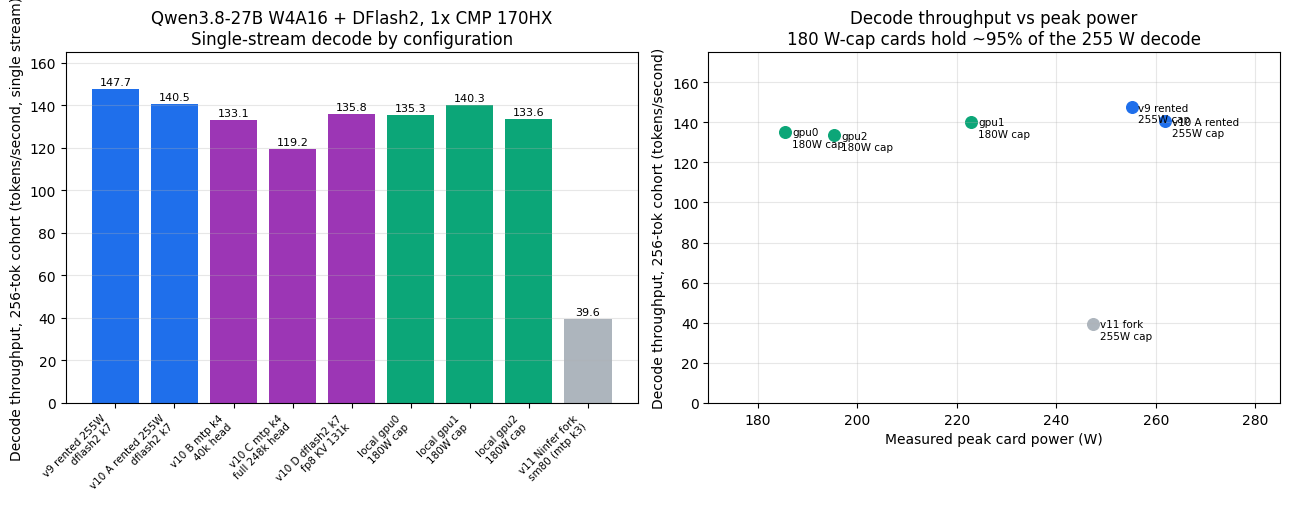

saved: assets/charts/2026-08-30-qwen3.8-27b-w4a16-dflash2-1card-vllm.{png,svg}


In [10]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.2))

labels = [
    "v9 rented 255W\ndflash2 k7",
    "v10 A rented 255W\ndflash2 k7",
    "v10 B mtp k4\n40k head",
    "v10 C mtp k4\nfull 248k head",
    "v10 D dflash2 k7\nfp8 KV 131k",
    "local gpu0\n180W cap",
    "local gpu1\n180W cap",
    "local gpu2\n180W cap",
    "v11 Ninfer fork\nsm80 (mtp k3)",
]
values = [
    v9["bench"]["decode256"]["decode_tok_s"],
    v10["boots"]["A"]["decode256_tok_s"],
    v10["boots"]["B"]["decode256_tok_s"],
    v10["boots"]["C"]["decode256_tok_s"],
    v10["boots"]["D"]["decode256_tok_s"],
] + [c["d256"] for c in cards] + [v11["results"]["decode256_tok_s"]]
colors = (["#1f6feb"] * 2 + ["#9c36b5"] * 3 + ["#0ca678"] * 3 + ["#adb5bd"])

bars = ax1.bar(range(len(values)), values, color=colors)
ax1.set_xticks(range(len(values)))
ax1.set_xticklabels(labels, rotation=45, ha="right", fontsize=7.5)
ax1.set_ylabel("Decode throughput, 256-tok cohort (tokens/second, single stream)")
ax1.set_title("Qwen3.8-27B W4A16 + DFlash2, 1x CMP 170HX\nSingle-stream decode by configuration")
for rect, val in zip(bars, values):
    ax1.annotate(f"{val:.1f}", xy=(rect.get_x() + rect.get_width() / 2, val),
                 xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8)
ax1.grid(True, axis="y", alpha=0.3)
ax1.set_ylim(0, 165)

pw = [
    ("v9 rented\n255W cap", v9["gpu_peak"]["power_w"], v9["bench"]["decode256"]["decode_tok_s"], "#1f6feb"),
    ("v10 A rented\n255W cap", v10["boots"]["A"]["gpu_peak"]["power_w"], v10["boots"]["A"]["decode256_tok_s"], "#1f6feb"),
    ("gpu0\n180W cap", cards[0]["peak_w"], cards[0]["d256"], "#0ca678"),
    ("gpu1\n180W cap", cards[1]["peak_w"], cards[1]["d256"], "#0ca678"),
    ("gpu2\n180W cap", cards[2]["peak_w"], cards[2]["d256"], "#0ca678"),
    ("v11 fork\n255W cap", v11["results"]["gpu_peak"]["power_w"], v11["results"]["decode256_tok_s"], "#adb5bd"),
]
for name, w, t, col in pw:
    ax2.scatter(w, t, s=70, color=col)
    ax2.annotate(name, xy=(w, t), xytext=(5, -11), textcoords="offset points", fontsize=7.5)
ax2.set_xlabel("Measured peak card power (W)")
ax2.set_ylabel("Decode throughput, 256-tok cohort (tokens/second)")
ax2.set_title("Decode throughput vs peak power\n180 W-cap cards hold ~95% of the 255 W decode")
ax2.grid(True, alpha=0.3)
ax2.set_xlim(170, 285)
ax2.set_ylim(0, 175)

fig.tight_layout()
os.makedirs("../assets/charts", exist_ok=True)
fig.savefig("../assets/charts/2026-08-30-qwen3.8-27b-w4a16-dflash2-1card-vllm.png", dpi=150)
fig.savefig("../assets/charts/2026-08-30-qwen3.8-27b-w4a16-dflash2-1card-vllm.svg")
plt.show()
print("saved: assets/charts/2026-08-30-qwen3.8-27b-w4a16-dflash2-1card-vllm.{png,svg}")

## 3. Reproduce

**Hardware.** 1x NVIDIA CMP 170HX (SM80 / compute capability 8.0-mining SKU,
64 GiB HBM2e, ~1.5 TB/s-class bandwidth). Measured host link on the rental:
PCIe Gen2 x4 — weight download/load is slow, steady-state inference is fine
once weights are resident. Power: 255 W default on the rental; 180 W cap on
our own box (95% of decode survives). Forced airflow required; the card
reaches 73 C core at 255 W and 51 C core / 52-61 C memory at 180 W.

**Software.** No private image needed (the private-GHCR shortcut failed; see
appendix). Public CUDA base image `nvidia/cuda:13.0.1-base-ubuntu24.04`, then
per the syv-ai repo's own instructions: `pip install vllm==0.27.1` per its
`docker/requirements.txt`, apply the repo's 20 patches, build the fast variant
(int4-GPTQ lm_head/MTP) and fetch the DFlash2 drafter. `onstart-v9.sh` in the
evidence bundle is the exact script this run used (names/paths masked). A
bigger-card must-do: symlink `curand.h` (and `nvcc`) from the pip CUDA packages
into `/usr/local/cuda/...`, or flashinfer's fast topk silently falls back to
`torch.topk`.

**Weights.** `dbirks/Qwen3.8-27B-W4A16-AutoRound` + fast variant built by the
repo's prepare chain (`prepare/quant_lm_head.py` etc.), drafter via
`prepare/fetch_dflash2.py`. Verify the fast variant actually built: the log
must show `FAST-VARIANT-PRESENT` (v6-v8 silently skipped it; that was the 4.5x
gap).

**Launch** (from the receipt; masked paths):

```bash
SPEC=dflash2 CTX=fast MAX_SEQS=1 DFLASH_TOKENS=7 PORT=18020 \
  GPU_UTIL=0.90 KV_MEM= VLLM_V2_CUDAGRAPH_MEM_MIB=1400 \
  bash single-user/start_qwen.sh
```

`KV_MEM=` empty is deliberate: the 5.2 GiB KV pin is a 24-GB-card constant
from the upstream defaults; unpinned on 64 GiB, the pool sizes to the full
65,536-token context.

**Bench.** `bench-usage.py` (bundle) drives the OpenAI-compatible API on
loopback: greedy (temperature 0), streaming with
`stream_options.include_usage`, 1 warmup + 3 samples per cohort; decode
cohorts use an 11-token prompt with `ignore_eos` at 256 and 900 completion
tokens; prefill uses a 6,603-token prompt. **Tokens are counted from the final
`usage` object**, never from SSE event counts (see appendix for why).

**Expected boot time.** Not captured in receipts for the rented v9 run (its
onstart also builds the venv and quantizes weights — budget tens of minutes on
first boot). For the local 180 W rerun with prebuilt weights, the per-card
receipts show launch → first bench sample in about 110 s (gpu1:
`started_at` 02:40:24 → bench metadata 02:42:15 UTC).

## 4. Appendix

<details>
<summary>Preflight, safety, failure history, and publication notes (click to expand)</summary>


### 4.1 Preflight and safety

Forced airflow confirmed before load on both hosts. Stop conditions per repo
policy: 80 C core / 85 C memory, stop on Xid, GPU disappearance, memory error,
or unsafe storage. Observed (measured, from `local-rerun-gpu*/` receipts and
`bench-v9/v10/v11.json`):

In [11]:
# Local 180 W rerun: post-run nvidia-smi counters + per-card bench peaks.
nvidia_after = load_text(os.path.join("local-rerun-gpu1", "nvidia-after.txt"))
def counter(name):
    for line in nvidia_after.splitlines():
        if name in line:
            return line.split(":")[-1].strip()
    return "not found"

preflight = [
    ("Core temp peak (own 180 W, across 3 cards)", "51 C"),
    ("Memory temp peak (own 180 W, across 3 cards)", "52-61 C"),
    ("Core temp peak (rented v9, 255 W)", "73 C"),
    ("HW thermal slowdown (own cards, post-run counter)", counter("HW Thermal Slowdown")),
    ("HW power braking (own cards, post-run counter)", counter("HW Power Braking")),
    ("SW power capping (own cards — expected under the 180 W cap)", counter("SW Power Capping")),
    ("Xid / ECC events (own box, kernel journal grep in run-local-card.sh)", "none recorded in receipts"),
    ("GPU disappearance", "none"),
]
render_table(["Check", "Observed"], preflight)

| Check | Observed |
|---|---|
| Core temp peak (own 180 W, across 3 cards) | 51 C |
| Memory temp peak (own 180 W, across 3 cards) | 52-61 C |
| Core temp peak (rented v9, 255 W) | 73 C |
| HW thermal slowdown (own cards, post-run counter) | Not Active |
| HW power braking (own cards, post-run counter) | 0 us |
| SW power capping (own cards — expected under the 180 W cap) | 1838655825 us |
| Xid / ECC events (own box, kernel journal grep in run-local-card.sh) | none recorded in receipts |
| GPU disappearance | none |

### 4.2 What went wrong (failure history, all from receipts)

- **v1 — private GHCR image.** The prebuilt `syv-ai` image 401'd an anonymous
  manifest request; the container never ran (~1.2 MiB filesystem, SSH shim
  only). Fix: skip private images entirely; a public CUDA base + the author's
  own pip/patch instructions reproduce the stack. A 401 on the anonymous
  manifest check predicts this failure in seconds.
- **v2-v5 — prepare.sh path bugs.** The prepare script `cd`s to `/app` but the
  clone lives at `/app/qwen-serving`; it died on a missing file *silently*
  (`|| echo continue`), so the fast variant was never built in v6-v8 either.
  Fix in v9: symlink `/app/prepare` to the clone's prepare dir; log then shows
  every quantize step and `FAST-VARIANT-PRESENT`.
- **v7 series.** Host path passed where a container path was needed; wrong
  draft repo name (twice); `huggingface-cli` removed in hub 1.27 → empty
  model dir crash. Five destroyed instances before v7e ran.
- **v7e — W8A16 negative result (kept).** Official dense W8A16 checkpoint:
  31.6 tok/s vs 47.5 W4A16, acceptance 2.9 vs 3.38. The card is
  bandwidth-bound; denser weights are strictly slower. The reference 212 tok/s
  is not reachable by weight precision alone.
- **Token counting bug (v6/v8).** SSE events were counted as tokens; with
  speculative decoding one event carries ~2.5-3 accepted tokens, so 43.3
  "tok/s" was really ~110-130. Fix: `stream_options.include_usage` and count
  `usage.completion_tokens`. This is why every number above is
  usage-token-counted.
- **KV pool mis-sized (v6).** Launcher pinned a 5.2 GiB KV slab (a 24-GB-card
  default), leaving ~58 GiB idle. Fix: `KV_MEM=` empty + `GPU_UTIL 0.90`.
- **flashinfer topk fallback (v6-v8).** JIT failed for lack of `nvcc`/`curand.h`
  and silently fell back to `torch.topk` (the DFlash2 selector wants flashinfer
  here). Fix: symlink `curand.h`/`nvcc` from the pip CUDA packages, clear the
  flashinfer cache.
- **v9a/v9b** — instance create returned stopped; destroyed immediately (nothing billed).
- **Superseded local 47.0 tok/s.** First local single-card run overlapped a
  docker build on the host and pinned a KV slab, under-measuring. Corrected
  2026-08-30 by the clean sequential rerun in section 2.4 (135.3-140.3 tok/s
  at 180 W). Both records preserved in `RESULTS.md`.
- **Multi-GPU 8x/4x rental attempt (failed before serving).** Instances created
  with 17-20 GB disks vs 168-176 GiB model sizes; one download died mid-stream
  (HF Xet background-writer error). Lesson: check
  `disk_space >= model_size + headroom` before creating any instance. No
  numbers produced, none invented.
- **v11 fork decode gap.** The sm_80 fork's groupwise-int + w8 kernels land
  3.5x behind the DFlash2 stack on decode — a negative result for decode, not a
  broken build. Its prefill path (419k tok/s) is the part worth porting. Also:
  the `[237/245] nvfp4_small_t.cu` build stall is ~20 minutes of real template
  instantiation, not a hang.


### 4.3 Publication and limitations

**What this shows (measured).** Single-stream decode/prefill for
Qwen3.8-27B W4A16 + DFlash2 k=7 on one CMP 170HX at 255 W (rented) and 180 W
(own box): 147.7 / 140.3 tok/s decode256, 134.5 / 124.8 tok/s decode900,
2156 / ~1955 tok/s prefill, TTFT 76 / ~190 ms. Plus two A/Bs on the same
node: Ninfer config tricks (v10) and the Ninfer sm_80 fork (v11).

**What this does not show.**

- **Multi-stream throughput.** MAX_SEQS=1 throughout. The often-quoted
  212.68 tok/s reference is an 8-stream aggregate per the syv repo's own
  tables (community-reported); chasing it means concurrency, which is
  untested here.
- **The 180 W vs 255 W comparison is cross-node** (rented card vs our cards).
  Same config and protocol, but v10 boot A re-measured the v9 config at 140.5
  vs 147.7 tok/s on a different rented card — treat ~5% as node-to-node
  spread (measured).
- **v11 comparability.** Chat-templated 63-token prompt vs 11 raw tokens,
  fork ignores `ignore_eos`, and its long-prefill cohort differs slightly
  (6,654 vs 6,603 prompt tokens, 8 vs 11 output tokens). Directional, not
  exact.
- **Acceptance length varies** (2.14-3.38 across receipts depending on run and
  recipe), so speculative speedups are distributions, not constants.
- **Billing figures are omitted** from this sanitized bundle (record kept
  upstream).
- **Text path only**; the vision tower is dropped in this recipe
  (`--language-model-only`).

**Links.**

- Upstream receipts: [PixelML/Qwen3.8-27B-CMP-170HX](https://github.com/PixelML/Qwen3.8-27B-CMP-170HX)
- Recipe repo (public): [syv-ai/qwen38-27b-rtx3090](https://github.com/syv-ai/qwen38-27b-rtx3090)
- sm_80 fork: [Ithrial/ninfer-cmp170hx](https://github.com/Ithrial/ninfer-cmp170hx)
- RTX 3090 baseline A/B: `rtx3090-baseline/` in this bundle (122.42 tok/s, 2.30x
  over its no-spec baseline, at a 390 W cap)


</details>
